正在跑 4845 組隨機森林訓練，請稍候...
已完成 1000 / 4845
已完成 2000 / 4845
已完成 3000 / 4845
已完成 4000 / 4845


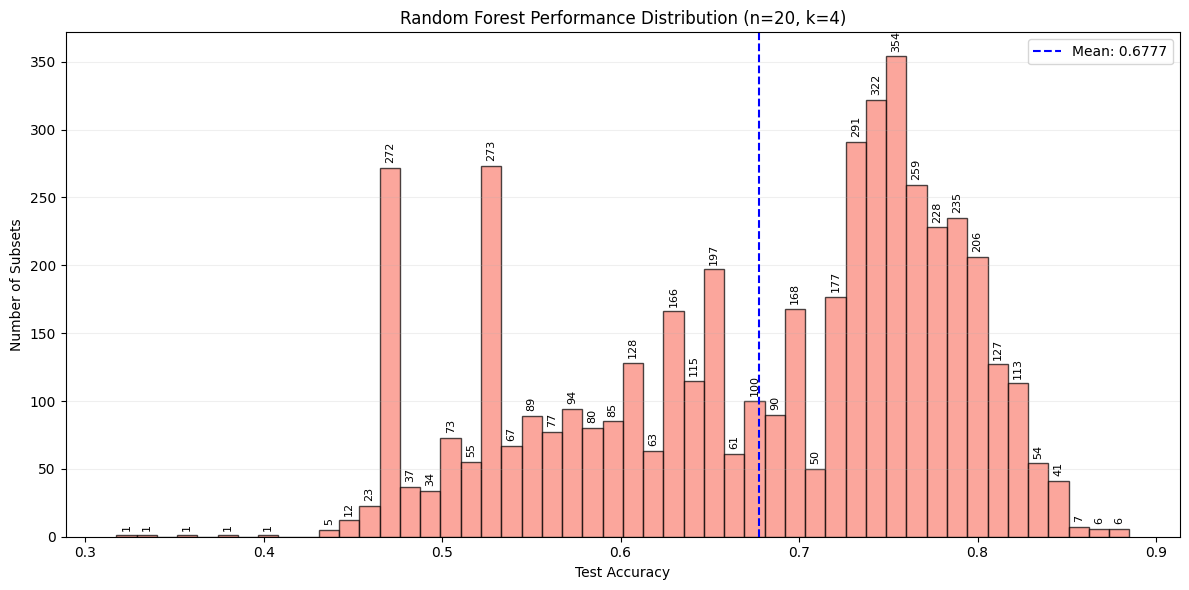

In [1]:
import torch
import numpy as np
from itertools import combinations
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. 資料集準備 (確保與先前實驗點位一致)
torch.manual_seed(42)
unlabeled_size = 20
label_budget = 4

# 生成與先前相同的 20 個 2D 點
data_tensor = torch.empty(unlabeled_size, 2).uniform_(-1, 1)
labels_tensor = (data_tensor[:, 1] >= data_tensor[:, 0]).float()

# 轉換為 NumPy 以便 sklearn 使用
X_pool = data_tensor.numpy()
y_pool = labels_tensor.numpy()

# 2. 建立測試集 (20x20 網格)
x_vals = np.linspace(-1, 1, 20)
y_vals = np.linspace(-1, 1, 20)
xv, yv = np.meshgrid(x_vals, y_vals)
X_test = np.vstack([xv.ravel(), yv.ravel()]).T
y_test = (X_test[:, 1] >= X_test[:, 0]).astype(float)

# 3. 窮舉所有組合
all_subsets = list(combinations(range(unlabeled_size), label_budget))
rf_accuracies = []

print(f"正在跑 {len(all_subsets)} 組隨機森林訓練，請稍候...")

for i, subset_idx in enumerate(all_subsets):
    X_train = X_pool[list(subset_idx)]
    y_train = y_pool[list(subset_idx)]
    
    # 初始化隨機森林 (針對 4 個點的小樣本，限制樹的深度以防過擬合)
    rf = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
    
    # 處理標籤單一的情況 (如果選到的 4 個點標籤全一樣，RF 會預測常數)
    if len(np.unique(y_train)) < 2:
        preds = np.full(y_test.shape, y_train[0])
    else:
        rf.fit(X_train, y_train)
        preds = rf.predict(X_test)
        
    acc = accuracy_score(y_test, preds)
    rf_accuracies.append(acc)

    if (i + 1) % 1000 == 0:
        print(f"已完成 {i + 1} / {len(all_subsets)}")

# 4. 視覺化分佈圖 (比照你的要求加上數量標記)
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(rf_accuracies, bins=50, edgecolor='black', color='salmon', alpha=0.7)

# 標註每根柱子的數量
for i in range(len(patches)):
    count = n[i]
    if count > 0:
        x_pos = patches[i].get_x() + patches[i].get_width() / 2
        y_pos = patches[i].get_height()
        plt.text(x_pos, y_pos + (max(n) * 0.01), str(int(count)), 
                 ha='center', va='bottom', fontsize=8, rotation=90)

plt.axvline(np.mean(rf_accuracies), color='blue', linestyle='--', label=f'Mean: {np.mean(rf_accuracies):.4f}')
plt.xlabel('Test Accuracy')
plt.ylabel('Number of Subsets')
plt.title(f'Random Forest Performance Distribution (n=20, k=4)')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()

plt.savefig('RF_Accuracy_Distribution_n20_k4.png')
plt.show()